# Deep Operator Network (DeepONets) in Neuromancer: Learning nonlinear operators

This tutorial demonstrates the use of Deep Operator Network (DeepONets) for solving partial differential equations (PDEs) in the Neuromancer library.

<img src="https://media.springernature.com/lw685/springer-static/image/art%3A10.1038%2Fs42256-021-00302-5/MediaObjects/42256_2021_302_Fig1_HTML.png" width="700">  

## Deep Operator Networks (DeepONets)

DeepONets are neural networks designed to learn **operators**, i.e. mappings between functions,
$$
\mathcal{G} : v(\cdot) \;\mapsto\; u(\cdot),
$$
where $ v $ is an input function (e.g. a source term or coefficient field) and $ u $ is the corresponding output function (e.g. the PDE solution).

A DeepONet represents the operator evaluation at a point $ x $ as
$$
u(x) \approx \sum_{k=1}^{p} b_k(v)\, t_k(x),
$$
where:
- $ b_k(v) $ are outputs of the **branch network**, which encodes the input function $ v $ sampled at fixed sensor locations,
- $ t_k(x) $ are outputs of the **trunk network**, which encodes the spatial coordinate $ x $,
- $ p $ is the latent dimension.

Equivalently, this can be written as an inner product:
$$
u(x) \approx \mathbf{b}(v)^\top \mathbf{t}(x).
$$

In the **Cartesian-product formulation**, the same branch encoding $ \mathbf{b}(v) $ is paired with many spatial locations $ x $, allowing efficient evaluation of the output function on structured grids.

DeepONets provide a principled framework for learning solution operators of partial differential equations and have universal approximation properties for nonlinear operators.

### References

[1] [Lu, L., Jin, P., Pang, G. et al. Learning nonlinear operators via DeepONet based on the universal approximation theorem of operators. Nat Mach Intell 3, 218–229 (2021).](https://www.nature.com/articles/s42256-021-00302-5)

[2] https://github.com/jdtoscano94/Learning-Python-Physics-Informed-Machine-Learning-PINNs-DeepONets/tree/main

[3] [Lu, L., Meng, X., Cai, S., Mao, Z., Goswami, S., Zhang, Z., & Karniadakis, G. E. (2022). A comprehensive and fair comparison of two neural operators (with practical extensions) based on fair data. Computer Methods in Applied Mechanics and Engineering, 393, 114778.](https://www.sciencedirect.com/science/article/pii/S0045782522001207?via%3Dihub)

# Antiderivative Operator - Aligned Dataset

This tutorial demonstrates the use of learning DeepONets for a data driven use case (non-physics informed). This tutorial demonstrates usage of a Cartesian-product DeepONet implemented in Neuromancer, which is compatible with `neuromancer.modules.blocks` (or any `nn.Module`). The capability to use DeepONets from DeepXDE library within Neuromancer is also demonstrated. Here, we use `dde.nn.DeepONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`


### References
[1] [Antiderivative operator from an aligned dataset - DeepXDE](https://deepxde.readthedocs.io/en/latest/demos/operator/antiderivative_aligned.html)

[2] [DeepONet Tutorial in JAX](https://github.com/Ceyron/machine-learning-and-simulation/blob/main/english/neural_operators/simple_deepOnet_in_JAX.ipynb)

[3] [DeepXDE DeepONet PyTorch backend](https://deepxde.readthedocs.io/en/stable/_modules/deepxde/nn/pytorch/deeponet.html#)

[4] https://docs.nvidia.com/physicsnemo/25.08/physicsnemo-sym/user_guide/neural_operators/deeponet.html

### Install (Colab only)

In [10]:
# %pip install "neuromancer[examples] @ git+https://github.com/pnnl/neuromancer.git@master"
# %pip install watermark

### Imports

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
# PyTorch random seed
torch.manual_seed(1234)

# NumPy random seed
np.random.seed(1234)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Problem Setup

original source: [https://github.com/lululxvi/deepxde/blob/master/examples/operator/poisson_1d_pideeponet.py](https://github.com/lululxvi/deepxde/blob/master/examples/operator/poisson_1d_pideeponet.py)  

We will learn the 1D Poisson operator:

$$G : v \mapsto u$$

Find u on [0,1] such that -u_xx(x) = f(x) with Dirichlet u(0)=u(1)=0. Here f is not fixed; we learn the solution operator that maps any admissible f (from a small function space) to its corresponding u.

## Problem definition

In [3]:
# Poisson equation: -u_xx = f
def equation(x, y, f):
    dy_xx = dde.grad.hessian(y, x)
    return -dy_xx - f

In [4]:
# Domain is interval [0, 1]
geom = dde.geometry.Interval(0, 1)


# Zero Dirichlet BC
def u_boundary(_):
    return 0


def boundary(_, on_boundary):
    return on_boundary


# Dirichlet u(0)=u(1)=0
bc = dde.icbc.DirichletBC(geom, u_boundary, boundary)

## Dataset Prep

PDE residual points: `num_domain=100` interior samples from geom (`pde.train_x` stores them, plus boundary points)

In [5]:
# Define PDE
pde = dde.data.PDE(geom, equation, bc, num_domain=100, num_boundary=2)

### Why there are 104 trunk points

The trunk input contains 104 points because boundary points are intentionally included **twice** during PDE dataset construction.

- In `PDE.train_points()`, `num_boundary = 2` boundary points are added to the interior collocation points, producing  
  `(num_domain + num_boundary) = 100 + 2 = 102` points in `train_x_all`.

- In `PDE.bc_points()`, the boundary subset `train_x_bc` (length 2) is extracted from `train_x_all` for enforcing boundary conditions.

As a result, the boundary points appear once at the beginning for the boundary-condition loss and again within the PDE residual block.

- The **first 2 points** are used exclusively for the boundary-condition loss.
- The **remaining 102 points** are used for the PDE residual, including the same boundary points plus the 100 interior points.


In [19]:
n_bc = sum(pde.num_bcs)
print(n_bc)
print("train_x", pde.train_x.shape)
print("train_x_all", pde.train_x_all.shape)
print("test_x ", pde.test_x.shape)
print("BC x identical on test/train? ", np.allclose(pde.test_x[:n_bc], pde.train_x_bc))
print("PDE x identical on test/train?", np.allclose(pde.test_x[n_bc:], pde.train_x_all))

2
train_x (104, 1)
train_x_all (102, 1)
test_x  (104, 1)
BC x identical on test/train?  True
PDE x identical on test/train? True


In [9]:
print(pde.train_x_all.shape)  # (102, 1)
print(pde.train_x_bc.shape)  # (102, 1)
print(pde.train_x.shape)  # (102, 1)

(102, 1)
(2, 1)
(104, 1)


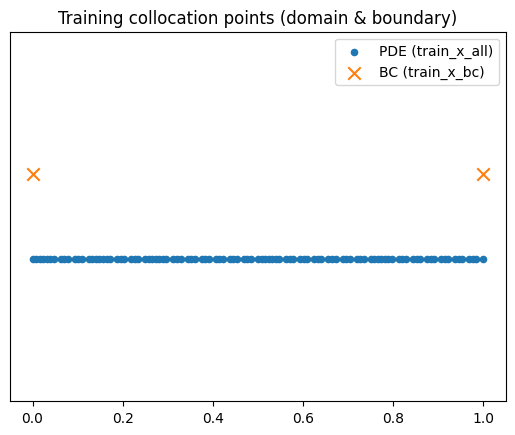

In [20]:
# grab points, display x-cordinates
X_bc = np.asarray(pde.train_x_bc)[:, 0]  # boundary points
X_pde = np.asarray(pde.train_x_all)[:, 0]  # interior PDE points

plt.figure()
plt.scatter(X_pde, np.zeros_like(X_pde), s=20, label="PDE (train_x_all)")
plt.scatter(X_bc, np.zeros_like(X_bc) + 0.03, s=80, marker="x", label="BC (train_x_bc)")
plt.yticks([])
plt.ylim(-0.05, 0.08)
plt.title("Training collocation points (domain & boundary)")
plt.legend()
plt.show()

## Discretised $f$ for branch net

Here $f$ is not fixed; we learn the solution operator that maps any admissible $f$ (from a small function space) to its corresponding $u$

In [21]:
# Function space for f(x) are polynomials
degree = 3
space = dde.data.PowerSeries(N=degree + 1)

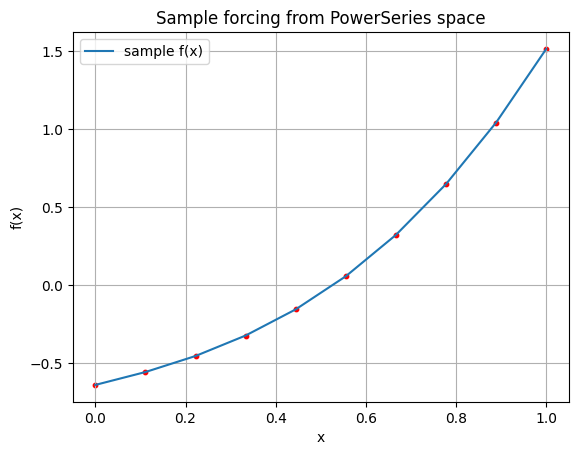

In [22]:
# sample one coefficient vector and build f(x)
coeffs = space.random(21)[0]  # shape (degree+1,)
# xs = np.linspace(0, 1, 200)
xs = geom.uniform_points(10, boundary=True)
f_vals = sum(coeffs[k] * xs**k for k in range(len(coeffs)))

plt.figure()
plt.plot(xs, f_vals, label="sample f(x)")
plt.scatter(xs, f_vals, s=10, color="red")
plt.title("Sample forcing from PowerSeries space")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

We chose to evaluate $f$ on `num_eval_points = 10` points. They are uniformly spaced

In [23]:
# Choose evaluation points, mark on geom
num_eval_points = 10
evaluation_points = geom.uniform_points(num_eval_points, boundary=True)

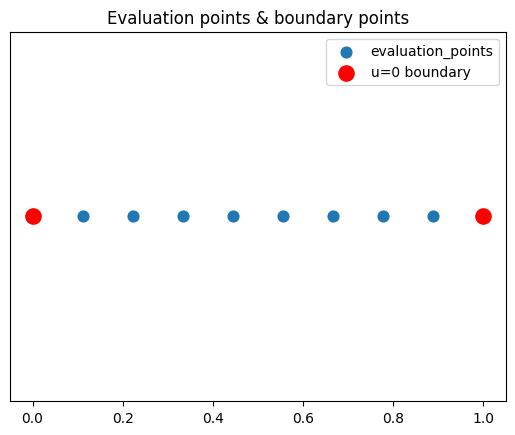

In [24]:
plt.figure()
plt.scatter(
    evaluation_points, np.zeros_like(evaluation_points), s=60, label="evaluation_points"
)
plt.scatter([0, 1], [0, 0], color="red", s=120, label="u=0 boundary")
plt.yticks([])
plt.ylim(-0.1, 0.1)
plt.xlim(-0.05, 1.05)
plt.title("Evaluation points & boundary points")
plt.legend()
plt.show()

`PDEOperatorCartesianProd` builds the operator-learning dataset

It samples `num_function` random f from `function_space`, evaluates them at `evaluation_points` for branch inputs, evaluates them at all PDE collocation points for auxiliary vars, and pairs each branch sample with the fixed trunk grid.

After construction, `pde_op` contains the following fields:

- **`pde_op.eval_pts`**  
  The evaluation points used to sample each function $f$ for the branch network.  
  Shape: `(num_eval_points,) = (10,)`

- **`pde_op.train_x`**  
  Tuple `(func_vals, pde.train_x)` containing branch and trunk inputs.

  - **`func_vals`**  
    Branch inputs: values of each sampled function evaluated at `eval_pts`.  
    Shape: `(num_function, num_eval_points) = (100, 10)`

  - **`pde.train_x`**  
    Trunk inputs: PDE collocation points (interior + boundary).  
    Shape: `(num_domain + num_boundary, dim) = (102, 1)`

In [ ]:
# Define PDE operator
pde_op = dde.data.PDEOperatorCartesianProd(
    pde=pde,
    function_space=space,
    evaluation_points=evaluation_points,
    num_function=100,
    num_test=20,
)

In [83]:
# Branch inputs: f values at the 10 evaluation points
f_vals, x_trunk = pde_op.train_x  # f_vals shape: (100, 10); x_trunk shape: (~102, 1)
eval_pts = pde_op.eval_pts  # same 10-point grid used for branch inputs
f_trunk = pde_op.train_aux_vars  # (Nf, m_trunk) = f(x) on trunk grid
print("x_trunk.shape ", x_trunk.shape)
print("f_vals.shape    ", f_vals.shape)
print("f_trunk.shape ", f_trunk.shape)

x_trunk.shape  (104, 1)
f_vals.shape     (100, 10)
f_trunk.shape  (100, 104)


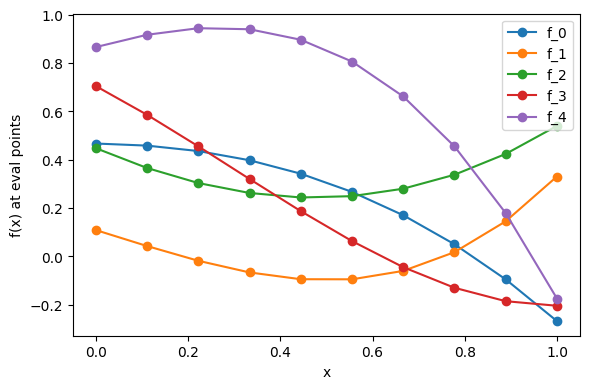

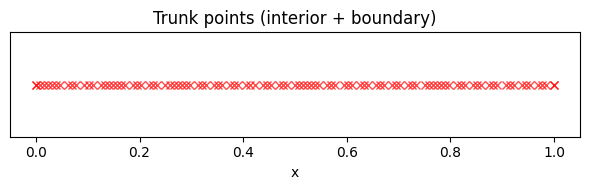

In [84]:
# Plot a few sampled source terms on the eval grid
plt.figure(figsize=(6, 4))
for i in range(5):
    plt.plot(eval_pts[:, 0], f_vals[i], marker="o", label=f"f_{i}")
plt.xlabel("x")
plt.ylabel("f(x) at eval points")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize trunk (PDE collocation + boundary) points
plt.figure(figsize=(6, 2))
plt.plot(x_trunk[:, 0], np.zeros_like(x_trunk[:, 0]), "rx", alpha=0.7)
plt.xlabel("x")
plt.yticks([])
plt.title("Trunk points (interior + boundary)")
plt.tight_layout()
plt.show()

In [85]:
(f_vals_test, x_trunk_test) = pde_op.test_x
f_trunk_test = pde_op.test_aux_vars  # (Nf, m_trunk) = f(x) on trunk grid

In [86]:
print("x_trunk_test.shape ", x_trunk_test.shape)
print("f_vals_test.shape    ", f_vals_test.shape)
print("f_trunk_test.shape ", f_trunk_test.shape)

x_trunk_test.shape  (104, 1)
f_vals_test.shape     (20, 10)
f_trunk_test.shape  (20, 104)


## Creating datasets for Neuromancer

- Branch input shape (`num_function, num_eval_points`) = (100,10): values of each sampled $f$ at the 10 evaluation points.
- Trunk input shape (`num_pde_pts`, `dim_x`) = (`pde.train_x.shape[0]`, `1`): spatial coordinates used for PDE residual + BC enforcement.


`requires_grad_()` here ensures the trunk coords participate in autograd when we differentiate `u(x)`. This will be needed for physics losses


In [88]:
from neuromancer.dataset import DictDataset

branch_inputs = torch.as_tensor(f_vals, dtype=torch.float32)  # (Nf, m_eval)
trunk_grid = torch.as_tensor(x_trunk, dtype=torch.float32)  # (m_trunk, dim_x)
trunk_inputs = trunk_grid.expand(
    branch_inputs.shape[0], -1, -1
).requires_grad_()  # (Nf, m_trunk, dim_x) shared grid, grad on for physics loss
f_out_trunk = torch.as_tensor(f_trunk, dtype=torch.float32)  # (Nf, m_trunk)

train_datadict = DictDataset(
    {
        "branch_inputs": branch_inputs,
        "trunk_inputs": trunk_inputs,
        "outputs": f_out_trunk,
    },
    name="train",
)

In [89]:
branch_inputs_test = torch.as_tensor(f_vals_test, dtype=torch.float32)  # (Nf, m_eval)
trunk_grid_test = torch.as_tensor(x_trunk_test, dtype=torch.float32)  # (m_trunk, dim_x)
trunk_inputs_test = trunk_grid_test.expand(
    branch_inputs_test.shape[0], -1, -1
).requires_grad_()  # (Nf, m_trunk, dim_x) shared grid, grad on for physics loss
f_out_trunk_test = torch.as_tensor(f_trunk_test, dtype=torch.float32)  # (Nf, m_trunk)

test_datadict = DictDataset(
    {
        "branch_inputs": branch_inputs_test,
        "trunk_inputs": trunk_inputs_test,
        "outputs": f_out_trunk_test,
    },
    name="test",
)

### Create named dictionary datasets

In [ ]:
# check dimensions
print("Dimensions check:")
print("Train branch:", train_datadict.datadict["branch_inputs"].shape)  # (Nf, m_eval)
print("Train output:", train_datadict.datadict["outputs"].shape)  # (Nf, m_trunk)
print(
    "Train trunk:", train_datadict.datadict["trunk_inputs"].shape
)  # (Nf, m_trunk, dim_x)

print("Train branch:", test_datadict.datadict["branch_inputs"].shape)  # (Nf, m_eval)
print("Train output:", test_datadict.datadict["outputs"].shape)  # (Nf, m_trunk)
print(
    "Train trunk:", test_datadict.datadict["trunk_inputs"].shape
)  # (Nf, m_trunk, dim_x)

Dimensions check:
Train branch: torch.Size([100, 10])
Train output: torch.Size([100, 104])
Train trunk: torch.Size([100, 104, 1])
Train branch: torch.Size([20, 10])
Train output: torch.Size([20, 104])
Train trunk: torch.Size([20, 104, 1])


### Create torch DataLoaders for the Trainer

In [91]:
batch_size = 20
print(f"batch_size: {batch_size}")
train_loader = torch.utils.data.DataLoader(
    train_datadict,
    batch_size=batch_size,
    collate_fn=train_datadict.collate_fn,
    shuffle=False,
)
# dev_loader = torch.utils.data.DataLoader(
#     dev_datadict,
#     batch_size=batch_size,
#     collate_fn=dev_datadict.collate_fn,
#     shuffle=False,
# )
test_loader = torch.utils.data.DataLoader(
    test_datadict,
    batch_size=batch_size,
    collate_fn=test_datadict.collate_fn,
    shuffle=False,
)

batch_size: 20


# Define DeepONet

The branch net is chosen as a fully connected neural network of size `[num_eval_points, 32, 32]`, and the the trunk net is a fully connected neural network of size `[dim_x, 32, 32]`, where `dim_x` is dimension i.e. 1.

## Exporting DeepONet from DeepXDE in Neuromancer

We use the DeepONets available in the `dde.nn` from [DeepXDE](https://deepxde.readthedocs.io/en/latest/) library within Neuromancer. Here, we use `dde.nn.DeepONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`

In [92]:
# Setup DeepONet
dim_x = 1
p = 32
dde_deeponet = dde.nn.DeepONetCartesianProd(
    [num_eval_points, 32, p],
    [dim_x, 32, p],
    activation="tanh",
    kernel_initializer="Glorot normal",
)

A wrapper is needed for the DictDataset format to work with DeepXDE models.
`DeepXDEDataWrapper` makes DeepXDE models compatible with NeuroMANCER Nodes. DeepXDE expects a single tuple/list input (branch_inputs, trunk_inputs)

In [93]:
from neuromancer.modules.operators import DeepXDEWrapper
from neuromancer.system import Node

dde_deeponet_wrapped = DeepXDEWrapper(
    model=dde_deeponet,
    is_cartesian=True,
)

node_dde_deeponet = Node(
    dde_deeponet_wrapped,
    ["branch_inputs", "trunk_inputs"],
    ["g"],
    name="dde_deeponet",
)
print(node_dde_deeponet)

dde_deeponet(branch_inputs, trunk_inputs) -> g


### Forward pass

In [94]:
print("symbolic inputs:", node_dde_deeponet.input_keys)
print("symbolic outputs:", node_dde_deeponet.output_keys)

symbolic inputs: ['branch_inputs', 'trunk_inputs']
symbolic outputs: ['g']


In [95]:
# evaluate forward pass on the train data
net_out = node_dde_deeponet(train_datadict.datadict)
net_out["g"].shape

torch.Size([100, 104])

## Objective and Constraints in NeuroMANCER

We will use the physcis in

In [96]:
from neuromancer.problem import Problem
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss

# Vars
u = variable("g")  # DeepONet output u(x)
x = variable("trunk_inputs")  # (B, m, 1) with requires_grad=True
f = variable("outputs")  # forcing f(x) on the same grid
num_bc = sum(pde.num_bcs)

# Derivatives
u_x = u.grad(x)  # (B, m, 1)
u_xx = u_x.grad(x)[:, :, 0]  # (B, m) — last dim removed

In [97]:
# check the shapes of the forward pass of the symbolic PINN terms
print(u_x({**net_out, **train_datadict.datadict}).shape)
print(u_xx({**net_out, **train_datadict.datadict}).shape)
print(f({**net_out, **train_datadict.datadict}).shape)

torch.Size([100, 104, 1])
torch.Size([100, 104])
torch.Size([100, 104])


In [98]:
# Poisson residual: -u_xx - f = 0
res_pde = (-u_xx - f)[:, num_bc:]  # keep PDE part
print(res_pde({**net_out, **train_datadict.datadict}).shape)


torch.Size([100, 102])


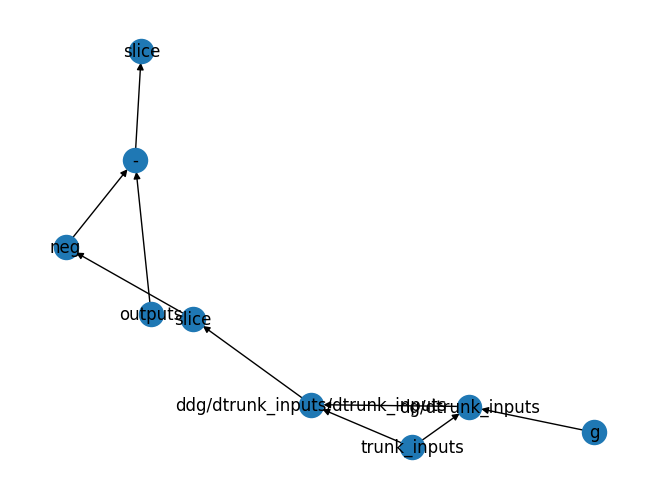

In [99]:
res_pde.show()

In [100]:
pde_loss = (res_pde == 0.0) ^ 2
pde_loss.name = "pde_residual"


In [101]:
# BC loss on the dedicated BC slice
u_bc = u[:, :num_bc]  # (B, 2)
bc_loss = (u_bc == 0.0) ^ 2
bc_loss.name = "bc_dirichlet"

In [102]:
print(u_bc({**net_out, **train_datadict.datadict}).shape)

torch.Size([100, 2])


In [103]:
objectives = [pde_loss, bc_loss]

loss = PenaltyLoss(objectives, constraints=[])

`Problem` setup using both DeepONets is similar. The Neuromancer library gives you the choice of seamlessly adding any approximator of choice in your `Problem` framework

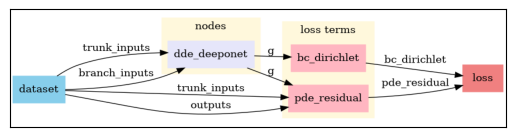

In [ ]:
problem = Problem(
    nodes=[node_dde_deeponet],  # list of nodes (neural nets) to be optimized
    loss=loss,  # physics-informed loss function
    grad_inference=True,
)  # argument for allowing computation of gradients at the inference time)
problem.show()  # graphviz library needed for graph visualization

## Problem Solution in NeuroMANCER

In [151]:
lr = 0.001  # step size for gradient descent
epochs = 50  # number of training epochs
epoch_verbose = 10  # print loss/display loss plot when this many epochs have occurred
warmup = 100  # number of epochs to wait before enacting early stopping policy
patience = 0  # number of epochs with no improvement in eval metric to allow before early stopping

optimizer = torch.optim.AdamW(problem.parameters(), lr=lr)
# optimizer = torch.optim.LBFGS(problem.parameters(),  maxiter=1000, lr=lr)


In [ ]:
# L-BFGS parameters
lr = 1.0  # L-BFGS typically uses lr=1.0
max_iter = 20  # max iterations per optimization step
tolerance_grad = 1e-7  # termination tolerance on first order optimality
tolerance_change = 1e-9  # termination tolerance on function value/parameter changes

optimizer = torch.optim.LBFGS(
    problem.parameters(),
    lr=lr,
    max_iter=max_iter,
    tolerance_grad=tolerance_grad,
    tolerance_change=tolerance_change,
    history_size=100,  # update history size
    line_search_fn="strong_wolfe",  # use line search for better convergence
)

### Construct Trainer and solve the problem

In [152]:
from neuromancer.trainer import Trainer
from neuromancer.callbacks import LossHistoryCallback

# define loss history callback using plots
loss_history_callback = LossHistoryCallback(plots_dir=None, show=True)
# dev_loader = train_loader  # reuse

# define trainer
trainer = Trainer(
    problem.to(device),
    train_data=train_loader,
    dev_data=train_loader,
    test_data=test_loader,
    optimizer=optimizer,
    logger=None,
    # callback=loss_history_callback,
    epochs=epochs,
    patience=patience,
    epoch_verbose=epoch_verbose,
    train_metric="train_loss",
    dev_metric="train_loss",
    test_metric="test_loss",
    eval_metric="train_loss",
    warmup=warmup,
    device=device,
)

In [153]:
%%time
best_model = trainer.train()

epoch: 0  train_loss: 0.5250043869018555
epoch: 10  train_loss: 0.5207992792129517
epoch: 20  train_loss: 0.5208176970481873
epoch: 30  train_loss: 0.5206999778747559
epoch: 40  train_loss: 0.5208843350410461
CPU times: user 2.53 s, sys: 342 ms, total: 2.87 s
Wall time: 2.9 s


In [154]:
# load best trained model
best_outputs = trainer.test(best_model)
problem.load_state_dict(best_model)

<All keys matched successfully>

In [155]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
# dev_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["dev"]]
mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
print(mean_test_loss)
print(f"len(train_loss_history): {len(train_loss_history)}")
# print(f"len(dev_loss_history): {len(dev_loss_history)}")

0.5622622
len(train_loss_history): 50


## Plot loss history w/ mean test loss

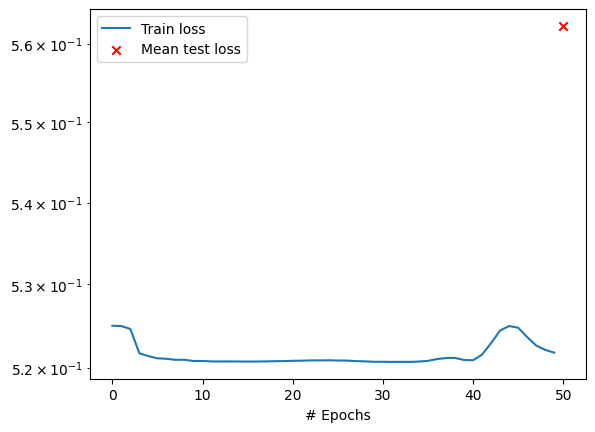

In [156]:
plt.semilogy(train_loss_history, label="Train loss")
# plt.semilogy(dev_loss_history, label="Dev loss")
plt.scatter(
    len(train_loss_history), mean_test_loss, label="Mean test loss", c="red", marker="x"
)
plt.xlabel("# Epochs")
plt.legend()
plt.show()

## Compare results on the test data

## Solution evaluation

Function space for $f$: ``PowerSeries(N=degree+1)`` with `degree`=3, so each random $f$ is a polynomial $a_0 + a_1 x + a_2 x^2 + a_3 x^3$; 

`space.random(num_function)` samples the coefficients of `f`.

`eval_batch` turns the coefficient vectors (`features`) into function values at those `evaluation_points=10` points

In [142]:
# Plot realisations of f(x)
n = 3
features = space.random(n)
fx = space.eval_batch(features, evaluation_points)

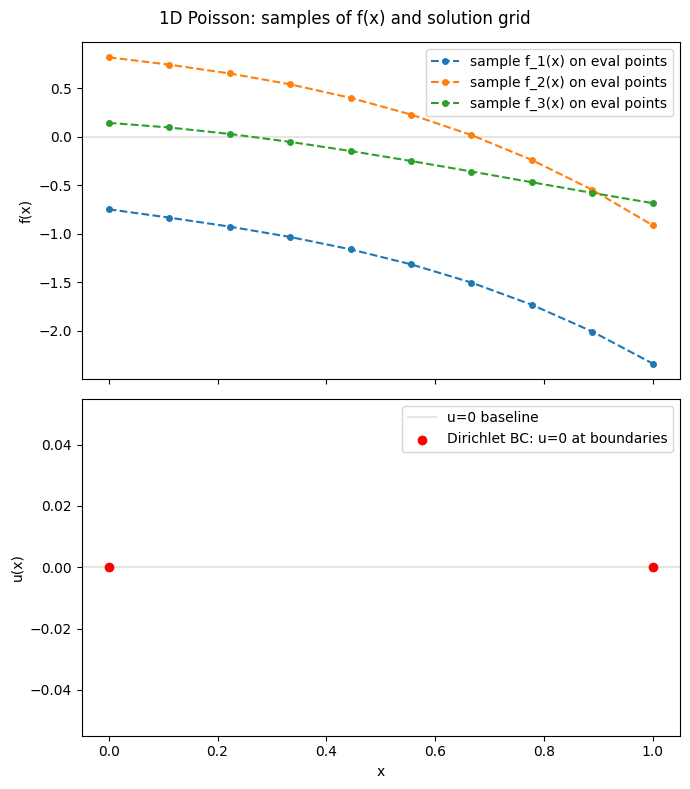

In [ ]:
x = geom.uniform_points(100, boundary=True)
z = np.zeros_like(x)

fig, (ax_f, ax_u) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
fig.suptitle("1D Poisson: samples of f(x) and solution grid")

# Source terms f(x)
ax_f.set_ylabel("f(x)")
ax_f.axhline(0, color="k", alpha=0.1)
for i in range(n):
    ax_f.plot(
        evaluation_points,
        fx[i],
        "--o",
        ms=4,
        label=f"sample f_{i + 1}(x) on eval points",
    )
ax_f.legend()

# Solution u(x) (placeholder)
ax_u.set_ylabel("u(x)")
ax_u.set_xlabel("x")
ax_u.axhline(0, color="k", alpha=0.1, label="u=0 baseline")
ax_u.scatter(
    [0, 1], [0, 0], color="red", zorder=3, label="Dirichlet BC: u=0 at boundaries"
)
# when we have predictions, add them, e.g.:
# y = model.predict(x)[:, 0]
# ax_u.plot(x, y, "-", label="predicted u(x)")
ax_u.legend()

plt.tight_layout()
plt.show()